In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,cohen_kappa_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree 



## Overall Goal: Find out what factors cause cancer to not develop in some animals

In [2]:
df = pd.read_csv('species_data (1).csv')

# Calculates: (Cancer Cases) / Total Population
df['cancer_rate'] = np.where(df['rec'] == 0, 0, (df['mal']) / df['rec']) * 100

# Create a mask to find rows where 'cancer_rate' is the max
df_sorted = df.sort_values(by='cancer_rate', ascending = False)

df_sorted.head(5)

,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate
151,Mustela_putorius,Mammalia,endothermic,Ferret,105,66,43,6.819361,5.837668,4.653960,40.952381
166,Panthera_onca,Mammalia,endothermic,Jaguar,22,10,9,11.512925,5.875148,3.091042,40.909091
27,Atelerix_albiventris,Mammalia,endothermic,Four-toed hedgehog,147,66,52,6.396930,5.605857,4.990433,35.374150
114,Lampropeltis_triangulum,Reptilia,ectothermic,Milk snake,46,18,16,7.549609,5.163459,3.828641,34.782609
121,Leptodactylus_fallax,Amphibia,ectothermic,Dominican mountain chicken frog,24,11,8,5.056246,5.780646,3.178054,33.333333


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Species      263 non-null    object 
 1   Class        263 non-null    object 
 2   therm        263 non-null    object 
 3   common_name  263 non-null    object 
 4   rec          263 non-null    int64  
 5   neo          263 non-null    int64  
 6   mal          263 non-null    int64  
 7   log_bm       263 non-null    float64
 8   log_pl       263 non-null    float64
 9   log_rec      263 non-null    float64
 10  cancer_rate  263 non-null    float64
dtypes: float64(4), int64(3), object(4)
memory usage: 22.7+ KB


In [4]:
bins = [-1, 2, 50] 
labels = [1,0]

df['cancer_class'] = pd.cut(df['cancer_rate'], bins=bins, labels=labels)
df['cancer_class'] = df['cancer_class'].astype('category')
df['Class'] = df['Class'].astype('category')
df['therm'] = df['therm'].astype('category')
# 1 = lots of cancer
# 0 = resistant to cancer

<Axes: xlabel='Class', ylabel='cancer_rate'>

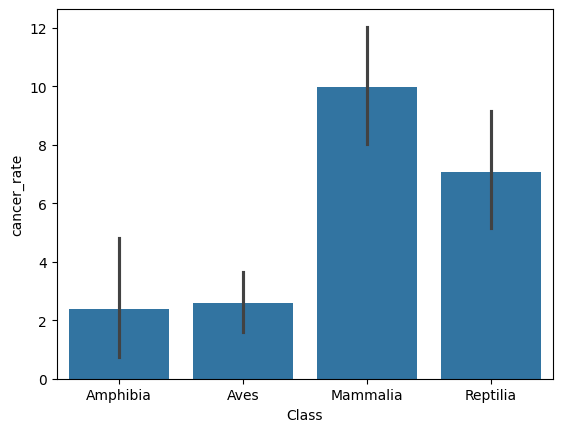

In [5]:
df = df.sort_values(by='cancer_rate', ascending = False)

sns.barplot(x = 'Class', y = 'cancer_rate', data = df)

# Woah! mammals have a significantly higher cancer rate than any other animal!
## that kinda sucks :( (Im a mammal)


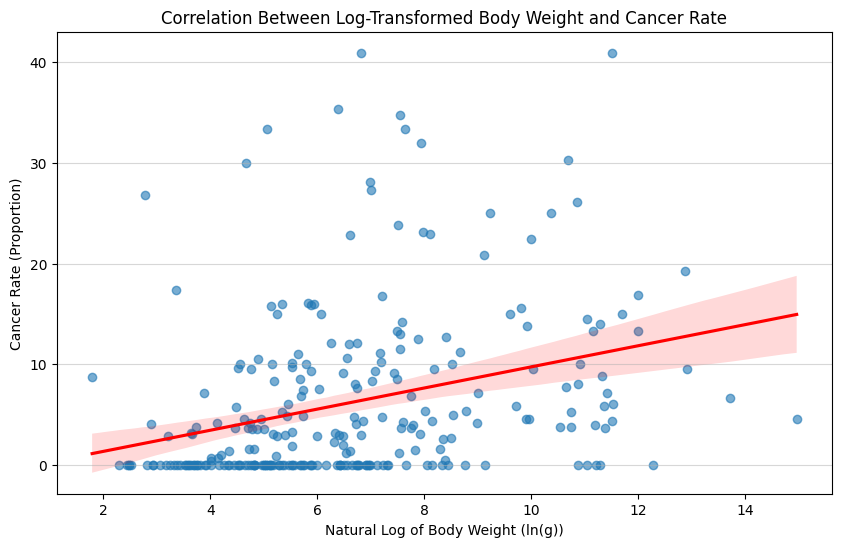

In [6]:

import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 6))
sns.regplot(
    x='log_bm',
    y='cancer_rate',
    data=df,
    scatter_kws={'alpha': 0.6},  # Set transparency for scatter points
    line_kws={'color': 'red'}    # Set the color of the regression line
)

# Add titles and labels for interpretation
plt.title('Correlation Between Log-Transformed Body Weight and Cancer Rate')
plt.xlabel('Natural Log of Body Weight (ln(g))')
plt.ylabel('Cancer Rate (Proportion)')
plt.grid(True, axis='y', alpha=0.5)

plt.show()



### Increased body wieght is correlated with an increase in cancer rates, however there are significant outliers

In [7]:

df = df.sort_values(by='log_bm', ascending = False)
df.head()


,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate,cancer_class
84,Elephas_maximus,Mammalia,endothermic,Asian elephant,22,9,1,14.966083,6.940684,3.091042,4.545455,0
102,Giraffa_camelopardalis,Mammalia,endothermic,Baringo giraffe,30,3,2,13.710144,6.421864,3.401197,6.666667,0
87,Equus_grevyi,Mammalia,endothermic,Grevys zebra,21,3,2,12.919022,6.481683,3.044522,9.523810,0
254,Ursus_maritimus,Mammalia,endothermic,Polar bear,26,8,5,12.870693,5.880296,3.258097,19.230769,0
244,Tragelaphus_strepsiceros,Mammalia,endothermic,Kudu,48,3,0,12.271397,6.294976,3.871201,0.000000,1



### The kudu, despite having 48 instances, has NOBODY with cancer! amazing!

## Adding a Diet Column

In [9]:
def get_diet(name):
    name = str(name).strip().lower()

    overrides = {
        'red panda': 'Herbivore', 'polar bear': 'Carnivore', 'green iguana': 'Herbivore',
        'guinea pig': 'Herbivore', 'feathertail glider': 'Omnivore', 'copperhead': 'Carnivore',
        'vampire bat': 'Carnivore', 'common marmoset': 'Omnivore', 'bald eagle': 'Carnivore',
        'gorilla': 'Herbivore', 'chimpanzee': 'Omnivore', 'koala': 'Herbivore',
        'snow leopard': 'Carnivore', 'white bengal tiger': 'Carnivore', 'domestic rabbit': 'Herbivore',
        'caribou': 'Herbivore', 'addax': 'Herbivore', 'common porpoise': 'Carnivore',
        'peninsular pronghorn': 'Herbivore', 'southern gerenuk': 'Herbivore',
        'greater rhea': 'Herbivore', 'collared peccary': 'Omnivore', 'mandrill': 'Omnivore',
        'nine-banded armadillo': 'Omnivore', 'abdims stork': 'Carnivore',
        'brown pelican': 'Carnivore', 'rock hyrax': 'Herbivore', 'red-rumped agouti': 'Herbivore',
        'lampropeltis getula': 'Carnivore', 'black faced ibis': 'Carnivore',
        'ajaia ajaja': 'Carnivore', 'opossum': 'Omnivore', 'red kite': 'Carnivore',
        'black hornbill': 'Omnivore', 'crotalus polystictus': 'Carnivore',
        'northern pintail': 'Omnivore', 'varanus salvadorii': 'Carnivore',
        'bothriechis schlegelii': 'Carnivore', 'grey_winged robin_chat': 'Omnivore',
        'seba short-tailed bat': 'Carnivore', 'zanzibar bishop': 'Herbivore',
        'california leaf-nosed bat': 'Carnivore', 'red cheeked cordon bleu': 'Herbivore',
        'slender tail meerkat': 'Carnivore',
        'elegant crested tinamou': 'Omnivore',
        'scarlet ibis': 'Carnivore',
        'new england cottontail': 'Herbivore',
        'chestnut-mandibled toucan': 'Omnivore',
        'rio couca caecilian': 'Carnivore',
        'hooded merganser': 'Carnivore',
        'hammerkop': 'Carnivore',
        'gaboon caecilian': 'Carnivore',
        'gila monster': 'Carnivore',
        'violet plaintain eater': 'Herbivore',
        'varanus beccarii': 'Carnivore',
        'bakers spiny tail iguana': 'Herbivore',
        'axolotl': 'Carnivore',
        'red crested turaco': 'Herbivore',
        'black-necked aracari': 'Omnivore',
        'plumed basilik': 'Carnivore',
        'sauromalus obesus': 'Herbivore',
        'inca tern': 'Carnivore',
        'roul roul': 'Omnivore',
        'sun bittern': 'Carnivore',
        'degu': 'Herbivore',
        'hardun sling-tailed agama': 'Herbivore',
        'black capped lory': 'Herbivore',
        'northern bobwhite': 'Omnivore',
        'red lory': 'Herbivore',
        'corncrake': 'Omnivore',
        'red headed rock agama': 'Herbivore',
        'chattering lory': 'Herbivore',
        'elgaria kingii': 'Carnivore',
        'mount apo lorikeet': 'Herbivore',
        'coconut lorikeet': 'Herbivore',
        'pygmy sugar glider': 'Omnivore',
        'long-haired rousette': 'Herbivore',
        'cockatiel': 'Herbivore',
        'bali mynah': 'Omnivore',
        'pygmy marmoset': 'Omnivore',
        'hooded pitta': 'Omnivore',
        'common field vole': 'Herbivore',
        'neophema splendida': 'Herbivore',
        'red-crested cardinal': 'Omnivore',
        'village weaver': 'Herbivore',
        'blue gray tanager': 'Omnivore',
        'golden mantella': 'Carnivore',
        'common shama': 'Carnivore',
        'budgerigar': 'Herbivore',
        'silver_beaked tanager': 'Omnivore',
        'java sparrow': 'Herbivore',
        'pekin robin': 'Omnivore'

    }
    # Check if any override key is in the name
    for key, value in overrides.items():
        if key in name: return value

    # 2. Keyword Rules (Order matters)

    # Carnivores (Meat/Insect eaters)
    carni_keywords = [
        'snake', 'viper', 'boa', 'python', 'cobra', 'adder', 'rattlesnake', 'frog', 'toad',
        'salamander', 'newt', 'eagle', 'hawk', 'falcon', 'owl', 'vulture', 'heron', 'egret',
        'penguin', 'seal', 'sealion', 'dolphin', 'otter', 'ferret', 'weasel', 'cat', 'lion',
        'tiger', 'leopard', 'cheetah', 'jaguar', 'wolf', 'fox', 'dog', 'monitor', 'gecko',
        'anole', 'lizard', 'chameleon', 'dragon', 'skink', 'bat', 'ibis', 'caecilian', 'monster', 'basilisk', 'tern'
    ]
    if any(k in name for k in carni_keywords): return 'Carnivore'

    # Herbivores (Plant eaters)
    herbi_keywords = [
        'gazelle', 'antelope', 'ibex', 'oryx', 'kudu', 'impala', 'zebra', 'giraffe', 'elephant',
        'hippo', 'rhino', 'cow', 'cattle', 'bison', 'sheep', 'goat', 'deer', 'elk', 'moose',
        'rabbit', 'hare', 'capybara', 'chinchilla', 'sloth', 'kangaroo', 'wallaby', 'fruit bat',
        'tortoise', 'parrot', 'macaw', 'cockatoo', 'dove', 'pigeon', 'finch', 'bird', 'duck', 'goose', 'swan', 'lory', 'turaco', 'agama'
    ]
    if any(k in name for k in herbi_keywords): return 'Herbivore'

    # Omnivores (Mixed eaters)
    omni_keywords = [
        'monkey', 'ape', 'lemur', 'baboon', 'macaque', 'tamarin', 'bear', 'raccoon', 'skunk',
        'badger', 'mouse', 'rat', 'hamster', 'squirrel', 'pig', 'hog', 'boar', 'chicken',
        'quail', 'turkey', 'duck', 'goose', 'swan', 'crow', 'raven', 'jay', 'starling', 'opossum', 'armadillo', 'peccary', 'hornbill', 'pintail', 'toucan', 'merganser', 'tinamou', 'aracari', 'lorikeet', 'glider', 'mynah', 'marmoset', 'pitta', 'vole', 'cardinal', 'weaver', 'tanager', 'sparrow', 'robin'
    ]
    if any(k in name for k in omni_keywords): return 'Omnivore'

    return 'Unknown'

# Apply the updated logic to the DataFrame
df['diet'] = df['common_name'].apply(get_diet)

# Save the modified DataFrame to a CSV file
df.to_csv('species_data_classified.csv', index=False)

# Verify if any species still have an 'Unknown' diet
unknown_diet_species = df[df['diet'] == 'Unknown']
unknown_count = len(unknown_diet_species)

if unknown_count > 0:
    print(f"There are {unknown_count} species with 'Unknown' diet remaining.")
    print("Unique common names with 'Unknown' diet:")
    for species in unknown_diet_species['common_name'].unique():
        print(species)
else:
    print("All species have been successfully classified with a diet type.")

All species have been successfully classified with a diet type.


In [10]:
df = pd.read_csv('species_data_classified.csv')
df.head()

,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate,cancer_class,diet
0,Elephas_maximus,Mammalia,endothermic,Asian elephant,22,9,1,14.966083,6.940684,3.091042,4.545455,0,Herbivore
1,Giraffa_camelopardalis,Mammalia,endothermic,Baringo giraffe,30,3,2,13.710144,6.421864,3.401197,6.666667,0,Herbivore
2,Equus_grevyi,Mammalia,endothermic,Grevys zebra,21,3,2,12.919022,6.481683,3.044522,9.523810,0,Herbivore
3,Ursus_maritimus,Mammalia,endothermic,Polar bear,26,8,5,12.870693,5.880296,3.258097,19.230769,0,Carnivore
4,Tragelaphus_strepsiceros,Mammalia,endothermic,Kudu,48,3,0,12.271397,6.294976,3.871201,0.000000,1,Herbivore


In [11]:
from IPython.display import display, FileLink  
import zipfile

df = pd.DataFrame(df)
df.to_csv('cancer_project.csv', index=False, encoding='utf-8')

# Preview
print(df.head())
print(f"\nShape: {df.shape} rows saved to 'cancer.csv'")

# Step 6: Zip and display download link 
with zipfile.ZipFile('cancer_project.zip', 'w') as z:
    z.write('cancer_project.csv')
display(FileLink('cancer_project.zip', result_html_prefix='Download your zipped submission: '))

                    Species     Class        therm      common_name  rec  neo  \
0           Elephas_maximus  Mammalia  endothermic   Asian elephant   22    9   
1    Giraffa_camelopardalis  Mammalia  endothermic  Baringo giraffe   30    3   
2              Equus_grevyi  Mammalia  endothermic     Grevys zebra   21    3   
3           Ursus_maritimus  Mammalia  endothermic       Polar bear   26    8   
4  Tragelaphus_strepsiceros  Mammalia  endothermic             Kudu   48    3   

   mal     log_bm    log_pl   log_rec  cancer_rate  cancer_class       diet  
0    1  14.966083  6.940684  3.091042     4.545455             0  Herbivore  
1    2  13.710144  6.421864  3.401197     6.666667             0  Herbivore  
2    2  12.919022  6.481683  3.044522     9.523810             0  Herbivore  
3    5  12.870693  5.880296  3.258097    19.230769             0  Carnivore  
4    0  12.271397  6.294976  3.871201     0.000000             1  Herbivore  

Shape: (263, 13) rows saved to 'cancer.csv'


C:\Users\USER\Data Science\cancer_project.zip

# Data Modeling


--- RANDOM FOREST CLASSIFICATION Performance ---
Accuracy: 0.6792452830188679
Precision: 0.6847203504043127
Recall: 0.6792452830188679
F1-score: 0.6757751634698475
Cohen's Kappa: 0.35596854896354535
  Feature  Importance
2  log_pl    0.392489
1  log_bm    0.364652
0   Class    0.195352
3    diet    0.047506


C:\Users\USER\AppData\Local\Temp\ipykernel_19512\3883283824.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


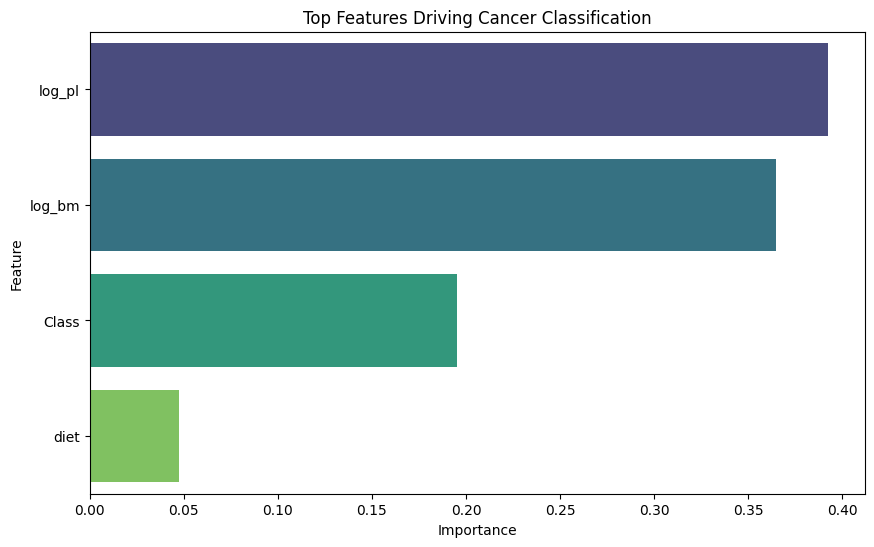

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score
)

# Load and clean data
df = pd.read_csv('species_data_classified.csv')
df = df.drop(columns=['Species', 'common_name', 'neo', 'mal', 'rec', 'therm', 'log_rec'], axis=1)

# Encode categorical variables
def encode(df):
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
    return df

df = encode(df)

# Split features and target
X = df.drop(columns=['cancer_class', 'cancer_rate'], axis=1)
y = df['cancer_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# ------------------------------
# Random Forest Model
# ------------------------------
model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
y_test_pred = model.predict(X_test)

# Evaluation
print("\n--- RANDOM FOREST CLASSIFICATION Performance ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1-score:", f1_score(y_test, y_test_pred, average='weighted'))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_test_pred))

# Feature Importances
importances = model.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_imp_df.head(10))

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp_df.head(10),
    palette='viridis'
)
plt.title('Top Features Driving Cancer Classification')
plt.show()


In [13]:
df = pd.read_csv('species_data_classified.csv')
df.head()

,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate,cancer_class,diet
0,Elephas_maximus,Mammalia,endothermic,Asian elephant,22,9,1,14.966083,6.940684,3.091042,4.545455,0,Herbivore
1,Giraffa_camelopardalis,Mammalia,endothermic,Baringo giraffe,30,3,2,13.710144,6.421864,3.401197,6.666667,0,Herbivore
2,Equus_grevyi,Mammalia,endothermic,Grevys zebra,21,3,2,12.919022,6.481683,3.044522,9.523810,0,Herbivore
3,Ursus_maritimus,Mammalia,endothermic,Polar bear,26,8,5,12.870693,5.880296,3.258097,19.230769,0,Carnivore
4,Tragelaphus_strepsiceros,Mammalia,endothermic,Kudu,48,3,0,12.271397,6.294976,3.871201,0.000000,1,Herbivore


In [14]:
def get_gestation(name):
    # Normalize the input name
    name = str(name).strip().lower()

    # Dictionary mapping lowercased common names to avg gestation/incubation days
    gestation_map = {
        # Mammals
        'asian elephant': 617,
        'baringo giraffe': 457,
        'grevys zebra': 390,
        'polar bear': 240,
        'kudu': 240,
        'white bengal tiger': 103,
        'masai lion': 110,
        'gorilla': 257,
        'guinea forest hog': 115,
        'atlantic harbor seal': 330,
        'jaguar': 101,
        'ringed seal': 330,
        'arabian oryx': 240,
        'caribou': 228,
        'warthog': 170,
        'common dolphin': 330,
        'california sealion': 350,
        'big horn sheep': 175,
        'addra gazelle': 195,
        'addax': 260,
        'nubian ibex': 150,
        'capybara': 150,
        'leopard': 96,
        'impala': 200,
        'common porpoise': 320,
        'mountain lion': 91,
        'cheetah': 93,
        'peninsular pronghorn': 250,
        'snow leopard': 100,
        'chimpanzee': 240,
        'southern gerenuk': 200,
        'gray wolf': 63,
        'cape hunting dog': 70,
        'collared peccary': 145,
        'thompsons gazelle': 165,
        "speke's gazelle": 180,
        'mandrill': 175,
        'colobus monkey': 170,
        'hamadryas baboon': 180,
        'koala': 35,
        'north americal river otter': 290,
        'goodfellows tree kangaroo': 44,
        'common raccoon': 63,
        'sulawesi crested macaque': 174,
        'linnes two-toed sloth': 300,
        'stuhlmans blue monkey': 140,
        'red panda': 130,
        'nine-banded armadillo': 260,
        'red/black ruffed lemur': 102,
        'rock hyrax': 230,
        'ring-tailed lemur': 135,
        'red-rumped agouti': 104,
        'domestic rabbit': 31,
        'white-faced saki monkey': 165,
        'gunnison prairie dog': 34,
        'fennec fox': 50,
        'opossum': 13,
        'ferret': 42,
        'black footed ferret': 42,
        'common squirrel monkey': 145,
        'slender tail meerkat': 70,
        'golden-headed tamarin': 130,
        'new england cottontail': 28,
        'black-capped squirrel monkey': 145,
        'four-toed hedgehog': 35,
        'tamarin monkey': 140,
        'chinchilla': 111,
        'emperor tamarins': 145,
        'brown rat': 21,
        'common marmoset': 144,
        'guinea pig': 65,
        'rodrigues fruit bat': 150,
        'straw-colored fruit bat': 120,
        'degu': 90,
        'egyptian fruit bat': 120,
        'pygmy sugar glider': 16,
        'long-haired rousette': 120,
        'vampire bat': 210,
        'pygmy marmoset': 135,
        'naked mole rat': 70,
        'common field vole': 21,
        'jamaican fruit bat': 115,
        'short-eared elephant shrew': 50,
        'pale spear-nosed bat': 100,
        'common dormouse': 24,
        'seba short-tailed bat': 115,
        'common mouse': 19,
        'feathertail glider': 15,
        'california leaf-nosed bat': 120,
        'harvest mouse': 17,

        # Birds (Incubation)
        'greater rhea': 40,
        'whooper swan': 35,
        'domestic lavender turkey': 28,
        'bald eagle': 35,
        'humboldt penguin': 40,
        'blue peafowl': 28,
        'abdims stork': 30,
        'brown pelican': 30,
        'black-footed penguin': 40,
        'rockhopper penguin': 34,
        'black faced ibis': 21,
        'ajaia ajaja': 22,
        'vulturine guineafowl': 25,
        'guinea fowl': 25,
        'red-breasted goose': 25,
        'superb fruit dove': 14,
        'red kite': 32,
        'black hornbill': 30,
        'northern pintail': 23,
        'radjah shelduck': 30,
        'greater prairie-chicken': 24,
        'aylesbury duck': 28,
        'salmon-crested cockatoo': 30,
        'domestic chicken': 21,
        'elegant crested tinamou': 19,
        'white faced tree duck': 28,
        'scarlet ibis': 21,
        'wood duck': 30,
        'chestnut-mandibled toucan': 16,
        'hooded merganser': 32,
        'ruddy duck': 23,
        'mandarin duck': 30,
        'hammerkop': 30,
        'cattle egret': 24,
        'violet plaintain eater': 23,
        'domestic pigeon': 17,
        'little egret': 21,
        'tawny frogmouth': 30,
        'red crested turaco': 28,
        'black-necked aracari': 16,
        'inca tern': 28,
        'roul roul': 18,
        'sun bittern': 28,
        'bleeding heart dove': 17,
        'soccoro dove': 14,
        'eastern screech-owl': 26,
        'black capped lory': 24,
        'northern bobwhite': 23,
        'gambel\'s quail': 22,
        'red lory': 25,
        'corncrake': 18,
        'chattering lory': 24,
        'splendid glossy_starling': 14,
        'mount apo lorikeet': 14,
        'blue-crowned mot mot': 20,
        'coconut lorikeet': 25,
        'cockatiel': 19,
        'black naped fruit dove': 14,
        'bali mynah': 14,
        'hooded pitta': 17,
        'african pygmy falcon': 30,
        'blue crowned lory': 25,
        'fischer\'s lovebird': 23,
        'black-cheeked lovebird': 23,
        'neophema splendida': 18,
        'red-crested cardinal': 13,
        'village weaver': 14,
        'blue gray tanager': 13,
        'common shama': 13,
        'budgerigar': 18,
        'silver_beaked tanager': 13,
        'java sparrow': 13,
        'chaffinch': 12,
        'pekin robin': 14,
        'grey_winged robin_chat': 14,
        'saffron finch': 13,
        'zanzibar bishop': 14,
        'timor zebra finch': 13,
        'red cheeked cordon bleu': 13,

        # Reptiles & Amphibians (Incubation/Gestation)
        'indian rock python': 60,
        'boa constrictor': 120,
        'diamond python': 50,
        'tiger rat snake': 75,
        'albino bull snake': 64,
        'boipevassu cobra': 60,
        'mangrove snake': 48,
        'boelens python': 65,
        'western diamond back rattlesnake': 160,
        'egyptian snouted cobra': 60,
        'lampropeltis getula': 60,
        'green tree python': 50,
        'emerald tree boa': 210,
        'madagscar tree boa': 180,
        'milk snake': 60,
        'timber rattlesnake': 150,
        'puff adder': 150,
        'corn snake': 60,
        'gaboon viper': 210,
        'tropical rattlesnake': 150,
        'dumerils boa': 210,
        'copperhead': 150,
        'rhinoceros viper': 210,
        'rosy boa': 120,
        'madagascar leaf-nosed snake': 65,
        'crotalus polystictus': 150,
        'wagler\'s pit viper': 180,
        'varanus salvadorii': 180,
        'rock rattlesnake': 150,
        'bothriechis schlegelii': 150,
        'pigmy rattlesnake': 150,
        'tentacled snake': 150,
        'rio couca caecilian': 220,
        'green iguana': 73,
        'atheris ceratophora': 60,
        'mexican beaded lizard': 120,
        'gaboon caecilian': 220,
        'eastern blue tongued skink': 100,
        'gila monster': 120,
        'varanus beccarii': 180,
        'tiger salamander': 14,
        'bakers spiny tail iguana': 80,
        'emerald monitor': 170,
        'axolotl': 14,
        'parsons chameleon': 400,
        'frilled dragon': 70,
        'reunion chameleon': 240,
        'plumed basilik': 60,
        'bearded dragon': 60,
        'veiled chameleon': 180,
        'cane toad': 3,
        'sauromalus obesus': 80,
        'hardun sling-tailed agama': 60,
        'dabb lizard': 70,
        'knight anole': 60,
        'surinam toad': 100,
        'collared tree lizard': 60,
        'chameleon forest dragon': 60,
        'leopard gecko': 45,
        'smoky jungle frog': 3,
        'asian horned frog': 7,
        'dominican mountain chicken frog': 10,
        'common toad': 10,
        'red headed rock agama': 60,
        'blue spiny lizard': 70,
        'elgaria kingii': 70,
        'eastern collared lizard': 50,
        'giant waxy tree frog': 8,
        'giant horned lizard': 70,
        'leaf tailed gecko': 90,
        'bell\'shorned frog': 3,
        'puerto rican crested toad': 3,
        'madagascar giant day gecko': 60,
        'tamato frog': 2,
        'common frog': 14,
        'striped newt': 14,
        'green climbing toad': 10,
        'standings day gecko': 65,
        'mission-eyed tree frog': 3,
        'satanic leaf-tailed gecko': 90,
        'sierra nevada yellow-legged frog': 14,
        'green tree frog': 5,
        'false poncelet\'s helmet skink': 65,
        'wyoming toad': 5,
        'panamanian golden frog': 7,
        'dyeing poison dart frog': 14,
        'iberian midwife toad': 22,
        'coastal tailed frog': 30,
        'golden poison arrow frog': 14,
        'bi-colour poison dart frog': 14,
        'mallorcan midwife toad': 22,
        'hourglass treefrog': 5,
        'golden mantella': 10,
        'beebe\'s rocket frog': 14,
    }

    # Check mapping
    if name in gestation_map:
        return gestation_map[name]
    
    # Return NaN or a placeholder if species not found
    return None

# Apply the function to the DataFrame
df['avg_gestation_incubation_days'] = df['common_name'].apply(get_gestation)

# Verify if any species were missed
missing_data = df[df['avg_gestation_incubation_days'].isna()]
missing_count = len(missing_data)

if missing_count > 0:
    print(f"There are {missing_count} species with missing gestation/incubation data.")
    print("Unique common names with missing data:")
    for species in missing_data['common_name'].unique():
        print(species)
else:
    print("All species have been successfully assigned a gestation/incubation period.")

All species have been successfully assigned a gestation/incubation period.


In [15]:
df

,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate,cancer_class,diet,avg_gestation_incubation_days
0,Elephas_maximus,Mammalia,endothermic,Asian elephant,22,9,1,14.966083,6.940684,3.091042,4.545455,0,Herbivore,617
1,Giraffa_camelopardalis,Mammalia,endothermic,Baringo giraffe,30,3,2,13.710144,6.421864,3.401197,6.666667,0,Herbivore,457
2,Equus_grevyi,Mammalia,endothermic,Grevys zebra,21,3,2,12.919022,6.481683,3.044522,9.523810,0,Herbivore,390
3,Ursus_maritimus,Mammalia,endothermic,Polar bear,26,8,5,12.870693,5.880296,3.258097,19.230769,0,Carnivore,240
4,Tragelaphus_strepsiceros,Mammalia,endothermic,Kudu,48,3,0,12.271397,6.294976,3.871201,0.000000,1,Herbivore,240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,Taeniopygia_guttata,Aves,endothermic,Timor zebra finch,29,1,0,2.488234,5.285390,3.367296,0.000000,1,Herbivore,13
259,Acrobates_pygmaeus,Mammalia,endothermic,Feathertail glider,43,0,0,2.484907,5.504776,3.761200,0.000000,1,Omnivore,15
260,Macrotus_californicus,Mammalia,endothermic,California leaf-nosed bat,23,0,0,2.451005,6.184557,3.135494,0.000000,1,Carnivore,120
261,Uraeginthus_bengalus,Aves,endothermic,Red cheeked cordon bleu,28,0,0,2.292535,5.290283,3.332205,0.000000,1,Herbivore,13


In [16]:
def get_lifespan(name):
    name = str(name).strip().lower()
    
    # Lifespan in DAYS (approximate maximum longevity in captivity)
    # 1 year = 365 days
    lifespan_map = {
        # --- MAMMALS ---
        'asian elephant': 29200,      # ~80 years
        'baringo giraffe': 13870,     # ~38 years
        'grevys zebra': 14600,        # ~40 years
        'polar bear': 16425,          # ~45 years
        'kudu': 8395,                 # ~23 years
        'white bengal tiger': 9490,   # ~26 years
        'masai lion': 10950,          # ~30 years
        'gorilla': 18250,             # ~50 years
        'guinea forest hog': 7300,    # ~20 years
        'atlantic harbor seal': 12775,# ~35 years
        'jaguar': 10220,              # ~28 years
        'ringed seal': 15695,         # ~43 years
        'arabian oryx': 7300,         # ~20 years
        'caribou': 7300,              # ~20 years
        'warthog': 6570,              # ~18 years
        'common dolphin': 21900,      # ~60 years
        'california sealion': 10950,  # ~30 years
        'big horn sheep': 8760,       # ~24 years
        'addra gazelle': 6935,        # ~19 years
        'addax': 9125,                # ~25 years
        'nubian ibex': 7300,          # ~20 years
        'capybara': 4380,             # ~12 years
        'leopard': 9855,              # ~27 years
        'impala': 6570,               # ~18 years
        'common porpoise': 7300,      # ~20 years
        'mountain lion': 7300,        # ~20 years
        'cheetah': 7300,              # ~20 years
        'peninsular pronghorn': 4380, # ~12 years
        'snow leopard': 9125,         # ~25 years
        'chimpanzee': 21900,          # ~60 years
        'southern gerenuk': 4745,     # ~13 years
        'gray wolf': 7300,            # ~20 years
        'cape hunting dog': 4015,     # ~11 years
        'collared peccary': 8760,     # ~24 years
        'thompsons gazelle': 5475,    # ~15 years
        "speke's gazelle": 4380,      # ~12 years
        'mandrill': 16790,            # ~46 years
        'colobus monkey': 10585,      # ~29 years
        'hamadryas baboon': 13687,    # ~37 years
        'koala': 6205,                # ~17 years
        'north americal river otter': 9125, # ~25 years
        'goodfellows tree kangaroo': 7300,  # ~20 years
        'common raccoon': 7300,       # ~20 years
        'sulawesi crested macaque': 12410, # ~34 years
        'linnes two-toed sloth': 10950,    # ~30 years
        'stuhlmans blue monkey': 11680,    # ~32 years
        'red panda': 7300,            # ~20 years
        'nine-banded armadillo': 8030,     # ~22 years
        'red/black ruffed lemur': 12045,   # ~33 years
        'rock hyrax': 4380,           # ~12 years
        'ring-tailed lemur': 11680,   # ~32 years
        'red-rumped agouti': 6570,    # ~18 years
        'domestic rabbit': 4380,      # ~12 years
        'white-faced saki monkey': 12775,  # ~35 years
        'gunnison prairie dog': 2920,      # ~8 years
        'fennec fox': 4380,           # ~12 years
        'opossum': 1460,              # ~4 years
        'ferret': 4380,               # ~12 years
        'black footed ferret': 4380,  # ~12 years
        'common squirrel monkey': 9490,    # ~26 years
        'slender tail meerkat': 4745,      # ~13 years
        'golden-headed tamarin': 5475,     # ~15 years
        'new england cottontail': 1825,    # ~5 years
        'black-capped squirrel monkey': 10950, # ~30 years
        'four-toed hedgehog': 2920,        # ~8 years
        'tamarin monkey': 8760,            # ~24 years
        'chinchilla': 7300,           # ~20 years
        'emperor tamarins': 7300,     # ~20 years
        'brown rat': 1460,            # ~4 years
        'common marmoset': 5840,      # ~16 years
        'guinea pig': 2920,           # ~8 years
        'rodrigues fruit bat': 10220, # ~28 years
        'straw-colored fruit bat': 10950,  # ~30 years
        'degu': 5110,                 # ~14 years
        'egyptian fruit bat': 9125,   # ~25 years
        'pygmy sugar glider': 4380,   # ~12 years
        'long-haired rousette': 7300, # ~20 years
        'vampire bat': 7300,          # ~20 years
        'pygmy marmoset': 4380,       # ~12 years
        'naked mole rat': 10950,      # ~30 years
        'common field vole': 1460,    # ~4 years
        'jamaican fruit bat': 3650,   # ~10 years
        'short-eared elephant shrew': 1460, # ~4 years
        'pale spear-nosed bat': 3650, # ~10 years
        'common dormouse': 1825,      # ~5 years
        'seba short-tailed bat': 3650,# ~10 years
        'common mouse': 1460,         # ~4 years
        'feathertail glider': 1825,   # ~5 years
        'california leaf-nosed bat': 7300, # ~20 years
        'harvest mouse': 1460,        # ~4 years

        # --- BIRDS ---
        'greater rhea': 14600,        # ~40 years
        'whooper swan': 9125,         # ~25 years
        'domestic lavender turkey': 4380,  # ~12 years
        'bald eagle': 18250,          # ~50 years
        'humboldt penguin': 10950,    # ~30 years
        'blue peafowl': 8395,         # ~23 years
        'abdims stork': 11315,        # ~31 years
        'brown pelican': 10950,       # ~30 years
        'black-footed penguin': 9855, # ~27 years
        'rockhopper penguin': 10585,  # ~29 years
        'black faced ibis': 9125,     # ~25 years
        'ajaia ajaja': 5475,          # ~15 years
        'vulturine guineafowl': 5475, # ~15 years
        'guinea fowl': 5475,          # ~15 years
        'red-breasted goose': 8760,   # ~24 years
        'superb fruit dove': 5475,    # ~15 years
        'red kite': 9490,             # ~26 years
        'black hornbill': 14600,      # ~40 years
        'northern pintail': 8030,     # ~22 years
        'radjah shelduck': 9125,      # ~25 years
        'greater prairie-chicken': 2920,   # ~8 years
        'aylesbury duck': 7300,       # ~20 years (Domestic Mallard)
        'salmon-crested cockatoo': 25550,  # ~70 years
        'domestic chicken': 4380,     # ~12 years
        'elegant crested tinamou': 5475,   # ~15 years
        'white faced tree duck': 5475,     # ~15 years
        'scarlet ibis': 10950,        # ~30 years
        'wood duck': 8030,            # ~22 years
        'chestnut-mandibled toucan': 8760, # ~24 years
        'hooded merganser': 4380,     # ~12 years
        'ruddy duck': 4745,           # ~13 years
        'mandarin duck': 7300,        # ~20 years
        'hammerkop': 7300,            # ~20 years
        'cattle egret': 8395,         # ~23 years
        'violet plaintain eater': 10950,   # ~30 years
        'domestic pigeon': 10950,     # ~30 years (extreme captive cases)
        'little egret': 7300,         # ~20 years
        'tawny frogmouth': 7300,      # ~20 years
        'red crested turaco': 10950,  # ~30 years
        'black-necked aracari': 7300, # ~20 years
        'inca tern': 7300,            # ~20 years
        'roul roul': 5475,            # ~15 years
        'sun bittern': 9125,          # ~25 years
        'bleeding heart dove': 5475,  # ~15 years
        'soccoro dove': 5475,         # ~15 years
        'eastern screech-owl': 5110,  # ~14 years
        'black capped lory': 9125,    # ~25 years
        'northern bobwhite': 2555,    # ~7 years
        'gambel\'s quail': 2555,      # ~7 years
        'red lory': 10220,            # ~28 years
        'corncrake': 2555,            # ~7 years
        'chattering lory': 10220,     # ~28 years
        'splendid glossy_starling': 7300,  # ~20 years
        'mount apo lorikeet': 7300,   # ~20 years
        'blue-crowned mot mot': 7300, # ~20 years
        'coconut lorikeet': 9125,     # ~25 years
        'cockatiel': 10950,           # ~30 years
        'black naped fruit dove': 5475,    # ~15 years
        'bali mynah': 7300,           # ~20 years
        'hooded pitta': 5475,         # ~15 years
        'african pygmy falcon': 5110, # ~14 years
        'blue crowned lory': 9125,    # ~25 years
        'fischer\'s lovebird': 7300,  # ~20 years
        'black-cheeked lovebird': 7300,    # ~20 years
        'neophema splendida': 5475,   # ~15 years
        'red-crested cardinal': 5475, # ~15 years
        'village weaver': 8760,       # ~24 years
        'blue gray tanager': 5475,    # ~15 years
        'common shama': 5475,         # ~15 years
        'budgerigar': 6570,           # ~18 years
        'silver_beaked tanager': 5475,# ~15 years
        'java sparrow': 3650,         # ~10 years
        'chaffinch': 4380,            # ~12 years
        'pekin robin': 7300,          # ~20 years
        'grey_winged robin_chat': 5475, # ~15 years
        'saffron finch': 3650,        # ~10 years
        'zanzibar bishop': 3650,      # ~10 years
        'timor zebra finch': 2920,    # ~8 years
        'red cheeked cordon bleu': 2920,   # ~8 years

        # --- REPTILES & AMPHIBIANS ---
        'indian rock python': 10950,  # ~30 years
        'boa constrictor': 14600,     # ~40 years
        'diamond python': 7300,       # ~20 years
        'tiger rat snake': 7300,      # ~20 years
        'albino bull snake': 9125,    # ~25 years
        'boipevassu cobra': 7300,     # ~20 years
        'mangrove snake': 7300,       # ~20 years
        'boelens python': 7300,       # ~20 years
        'western diamond back rattlesnake': 9125, # ~25 years
        'egyptian snouted cobra': 9125,    # ~25 years
        'lampropeltis getula': 9125,  # ~25 years
        'green tree python': 7300,    # ~20 years
        'emerald tree boa': 7300,     # ~20 years
        'madagscar tree boa': 7300,   # ~20 years
        'milk snake': 8030,           # ~22 years
        'timber rattlesnake': 10950,  # ~30 years
        'puff adder': 5475,           # ~15 years
        'corn snake': 11680,          # ~32 years
        'gaboon viper': 7300,         # ~20 years
        'tropical rattlesnake': 7300, # ~20 years
        'dumerils boa': 7300,         # ~20 years
        'copperhead': 10220,          # ~28 years
        'rhinoceros viper': 5475,     # ~15 years
        'rosy boa': 10950,            # ~30 years
        'madagascar leaf-nosed snake': 5475, # ~15 years
        'crotalus polystictus': 7300, # ~20 years
        'wagler\'s pit viper': 5475,  # ~15 years
        'varanus salvadorii': 7300,   # ~20 years
        'rock rattlesnake': 7300,     # ~20 years
        'bothriechis schlegelii': 5475,    # ~15 years
        'pigmy rattlesnake': 7300,    # ~20 years
        'tentacled snake': 5475,      # ~15 years
        'rio couca caecilian': 7300,  # ~20 years
        'green iguana': 7300,         # ~20 years
        'atheris ceratophora': 3650,  # ~10 years
        'mexican beaded lizard': 10950,    # ~30 years
        'gaboon caecilian': 5475,     # ~15 years
        'eastern blue tongued skink': 7300,# ~20 years
        'gila monster': 10950,        # ~30 years
        'varanus beccarii': 5475,     # ~15 years
        'tiger salamander': 9125,     # ~25 years
        'bakers spiny tail iguana': 7300,  # ~20 years
        'emerald monitor': 5475,      # ~15 years
        'axolotl': 9125,              # ~25 years
        'parsons chameleon': 4380,    # ~12 years
        'frilled dragon': 3650,       # ~10 years
        'reunion chameleon': 2555,    # ~7 years
        'plumed basilik': 3650,       # ~10 years
        'bearded dragon': 4380,       # ~12 years
        'veiled chameleon': 1825,     # ~5 years
        'cane toad': 5475,            # ~15 years
        'sauromalus obesus': 10950,   # ~30 years
        'hardun sling-tailed agama': 3650, # ~10 years
        'dabb lizard': 7300,          # ~20 years
        'knight anole': 3650,         # ~10 years
        'surinam toad': 2555,         # ~7 years
        'collared tree lizard': 2920, # ~8 years
        'chameleon forest dragon': 2920,   # ~8 years
        'leopard gecko': 8030,        # ~22 years
        'smoky jungle frog': 5475,    # ~15 years
        'asian horned frog': 2555,    # ~7 years
        'dominican mountain chicken frog': 4380, # ~12 years
        'common toad': 13140,         # ~36 years (record)
        'red headed rock agama': 3650,     # ~10 years
        'blue spiny lizard': 1825,    # ~5 years
        'elgaria kingii': 3650,       # ~10 years
        'eastern collared lizard': 2920,   # ~8 years
        'giant waxy tree frog': 5475, # ~15 years
        'giant horned lizard': 1825,  # ~5 years
        'leaf tailed gecko': 3650,    # ~10 years
        'bell\'shorned frog': 3650,   # ~10 years
        'puerto rican crested toad': 3650, # ~10 years
        'madagascar giant day gecko': 5475, # ~15 years
        'tamato frog': 2920,          # ~8 years
        'common frog': 3650,          # ~10 years
        'striped newt': 4380,         # ~12 years
        'green climbing toad': 3650,  # ~10 years
        'standings day gecko': 5475,  # ~15 years
        'mission-eyed tree frog': 5475,    # ~15 years
        'satanic leaf-tailed gecko': 2920, # ~8 years
        'sierra nevada yellow-legged frog': 5475, # ~15 years
        'green tree frog': 5475,      # ~15 years
        'false poncelet\'s helmet skink': 4380, # ~12 years
        'wyoming toad': 2920,         # ~8 years
        'panamanian golden frog': 4380,    # ~12 years
        'dyeing poison dart frog': 5475,   # ~15 years
        'iberian midwife toad': 1825, # ~5 years
        'coastal tailed frog': 5475,  # ~15 years
        'golden poison arrow frog': 5475,  # ~15 years
        'bi-colour poison dart frog': 5475,# ~15 years
        'mallorcan midwife toad': 3650,    # ~10 years
        'hourglass treefrog': 1825,   # ~5 years
        'golden mantella': 2920,      # ~8 years
        'beebe\'s rocket frog': 1825, # ~5 years
    }

    # Check mapping
    if name in lifespan_map:
        return lifespan_map[name]
    
    return None

# Apply the function to the DataFrame
df['avg_lifespan_days'] = df['common_name'].apply(get_lifespan)

# Verify if any species were missed
missing_lifespan = df[df['avg_lifespan_days'].isna()]
if len(missing_lifespan) > 0:
    print(f"Missing lifespan data for {len(missing_lifespan)} species.")
    print(missing_lifespan['common_name'].unique())
else:
    print("Lifespan data added successfully for all species.")

Lifespan data added successfully for all species.


In [17]:
df.sort_values(by = 'avg_lifespan_days')

,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate,cancer_class,diet,avg_gestation_incubation_days,avg_lifespan_days
262,Micromys_minutus,Mammalia,endothermic,Harvest mouse,23,3,2,1.791759,6.016344,3.135494,8.695652,0,Omnivore,17,1460
142,Rattus_norvegicus,Mammalia,endothermic,Brown rat,354,122,33,5.876895,5.496592,5.869297,9.322034,0,Omnivore,21,1460
95,Didelphis_marsupialis,Mammalia,endothermic,Opossum,96,34,27,6.995033,5.767396,4.564348,28.125000,0,Omnivore,13,1460
233,Microtus_agrestis,Mammalia,endothermic,Common field vole,62,0,0,3.749504,5.415857,4.127134,0.000000,1,Herbivore,21,1460
238,Macroscelides_proboscideus,Mammalia,endothermic,Short-eared elephant shrew,63,4,2,3.642836,5.383761,4.143135,3.174603,0,Herbivore,50,1460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,Gorilla_gorilla,Mammalia,endothermic,Gorilla,40,9,6,11.703133,5.688395,3.688879,15.000000,0,Herbivore,257,18250
29,Pan_troglodytes,Mammalia,endothermic,Chimpanzee,26,10,2,10.657259,5.668146,3.258097,7.692308,0,Omnivore,240,21900
15,Delphinus_delphis,Mammalia,endothermic,Common dolphin,31,0,0,11.289782,6.393078,3.433987,0.000000,1,Carnivore,330,21900
110,Cacatua_moluccensis,Aves,endothermic,Salmon-crested cockatoo,20,1,0,6.727420,4.739334,2.995732,0.000000,1,Herbivore,30,25550


In [18]:
def get_environment(name):
    name = str(name).strip().lower()

    # 1. Specific Species Overrides (Exact mappings for the provided dataset)
    env_map = {
        # --- AQUATIC (SALT WATER) ---
        'polar bear': 'Aquatic (Salt Water)', # Marine mammal, though lives on ice
        'atlantic harbor seal': 'Aquatic (Salt Water)',
        'ringed seal': 'Aquatic (Salt Water)',
        'common dolphin': 'Aquatic (Salt Water)',
        'california sealion': 'Aquatic (Salt Water)',
        'common porpoise': 'Aquatic (Salt Water)',
        'humboldt penguin': 'Aquatic (Salt Water)',
        'black-footed penguin': 'Aquatic (Salt Water)',
        'brown pelican': 'Aquatic (Salt Water)',
        'rockhopper penguin': 'Aquatic (Salt Water)',
        'inca tern': 'Aquatic (Salt Water)',
        'radjah shelduck': 'Aquatic (Salt Water)', # Coastal/Mangrove
        'scarlet ibis': 'Aquatic (Salt Water)', # Mangroves/Mudflats

        # --- AQUATIC (FRESH WATER) ---
        'whooper swan': 'Aquatic (Fresh Water)',
        'north americal river otter': 'Aquatic (Fresh Water)',
        'capybara': 'Aquatic (Fresh Water)',
        'rio couca caecilian': 'Aquatic (Fresh Water)',
        'hooded merganser': 'Aquatic (Fresh Water)',
        'ruddy duck': 'Aquatic (Fresh Water)',
        'mandarin duck': 'Aquatic (Fresh Water)',
        'scopus_umbretta': 'Aquatic (Fresh Water)', # Hammerkop
        'hammerkop': 'Aquatic (Fresh Water)',
        'little egret': 'Aquatic (Fresh Water)',
        'axolotl': 'Aquatic (Fresh Water)',
        'surinam toad': 'Aquatic (Fresh Water)',
        'common frog': 'Aquatic (Fresh Water)',
        'striped newt': 'Aquatic (Fresh Water)',
        'sierra nevada yellow-legged frog': 'Aquatic (Fresh Water)',
        'coastal tailed frog': 'Aquatic (Fresh Water)',
        'northern pintail': 'Aquatic (Fresh Water)',
        'aylesbury duck': 'Aquatic (Fresh Water)',
        'wood duck': 'Aquatic (Fresh Water)',
        'white faced tree duck': 'Aquatic (Fresh Water)',
        'tentacled snake': 'Aquatic (Fresh Water)',
        'boipevassu cobra': 'Aquatic (Fresh Water)', # False water cobra

        # --- DESERT (COLD) ---
        'caribou': 'Desert (Cold)', # Tundra
        'red-breasted goose': 'Desert (Cold)', # Tundra breeder

        # --- DESERT (HOT) ---
        'arabian oryx': 'Desert (Hot)',
        'addax': 'Desert (Hot)',
        'addra gazelle': 'Desert (Hot)',
        'fennec fox': 'Desert (Hot)',
        'slender tail meerkat': 'Desert (Hot)',
        'gila monster': 'Desert (Hot)',
        'bearded dragon': 'Desert (Hot)',
        'sauromalus obesus': 'Desert (Hot)',
        'dabb lizard': 'Desert (Hot)',
        'rosy boa': 'Desert (Hot)',
        'western diamond back rattlesnake': 'Desert (Hot)',
        'leopard gecko': 'Desert (Hot)',
        'blue spiny lizard': 'Desert (Hot)',
        'giant horned lizard': 'Desert (Hot)',
        'naked mole rat': 'Desert (Hot)',
        'california leaf-nosed bat': 'Desert (Hot)',
        'neophema splendida': 'Desert (Hot)',
        'short-eared elephant shrew': 'Desert (Hot)',
        'african pygmy falcon': 'Desert (Hot)',
        'gambel\'s quail': 'Desert (Hot)',
        'collared lizard': 'Desert (Hot)', # Crotaphytus collaris
        'eastern collared lizard': 'Desert (Hot)',

        # --- MOUNTAINS ---
        'big horn sheep': 'Mountains',
        'snow leopard': 'Mountains',
        'mountain lion': 'Mountains',
        'nubian ibex': 'Mountains',
        'rock hyrax': 'Mountains', # Rocky outcrops/kopjes
        'chinchilla': 'Mountains',
        'mallorcan midwife toad': 'Mountains',
        'rock rattlesnake': 'Mountains',
        'domestic pigeon': 'Mountains', # Rock dove origin (cliffs)
        'elgaria kingii': 'Mountains',

        # --- GRASSLANDS ---
        'asian elephant': 'Grasslands', # Scrub/Grassland/Forest mix
        'baringo giraffe': 'Grasslands',
        'grevys zebra': 'Grasslands',
        'kudu': 'Grasslands',
        'masai lion': 'Grasslands',
        'cheetah': 'Grasslands',
        'impala': 'Grasslands',
        'warthog': 'Grasslands',
        'peninsular pronghorn': 'Grasslands',
        'thompsons gazelle': 'Grasslands',
        'speke\'s gazelle': 'Grasslands',
        'southern gerenuk': 'Grasslands',
        'greater rhea': 'Grasslands',
        'cape hunting dog': 'Grasslands', # Wild Dog
        'domestic rabbit': 'Grasslands',
        'gunnison prairie dog': 'Grasslands',
        'greater prairie-chicken': 'Grasslands',
        'black footed ferret': 'Grasslands',
        'northern bobwhite': 'Grasslands',
        'elegant crested tinamou': 'Grasslands',
        'cattle egret': 'Grasslands',
        'guinea pig': 'Grasslands',
        'degu': 'Grasslands',
        'corncrake': 'Grasslands',
        'red headed rock agama': 'Grasslands',
        'cockatiel': 'Grasslands',
        'budgerigar': 'Grasslands',
        'java sparrow': 'Grasslands',
        'zebra finch': 'Grasslands',
        'timor zebra finch': 'Grasslands',
        'village weaver': 'Grasslands',
        'saffron finch': 'Grasslands',
        'harvest mouse': 'Grasslands',
        'common field vole': 'Grasslands',
        'red cheeked cordon bleu': 'Grasslands',
        'abdims stork': 'Grasslands',
        'guinea fowl': 'Grasslands',
        'vulturine guineafowl': 'Grasslands',
        'puff adder': 'Grasslands',
        'tropical rattlesnake': 'Grasslands',
        'crotalus polystictus': 'Grasslands',
        'eastern blue tongued skink': 'Grasslands',
        'frilled dragon': 'Grasslands',
        'red-crested cardinal': 'Grasslands',
        'fischer\'s lovebird': 'Grasslands',
        'nine-banded armadillo': 'Grasslands', # Scrub/Grassland

        # --- FOREST ---
        'gorilla': 'Forest',
        'chimpanzee': 'Forest',
        'orangutan': 'Forest',
        'white bengal tiger': 'Forest',
        'jaguar': 'Forest',
        'leopard': 'Forest',
        'clouded leopard': 'Forest',
        'guinea forest hog': 'Forest',
        'koala': 'Forest',
        'red panda': 'Forest',
        'sloth': 'Forest',
        'linnes two-toed sloth': 'Forest',
        'tamarin': 'Forest',
        'tamarin monkey': 'Forest',
        'emperor tamarins': 'Forest',
        'golden-headed tamarin': 'Forest',
        'marmoset': 'Forest',
        'common marmoset': 'Forest',
        'pygmy marmoset': 'Forest',
        'saki monkey': 'Forest',
        'white-faced saki monkey': 'Forest',
        'colobus monkey': 'Forest',
        'mandrill': 'Forest',
        'baboon': 'Grasslands', # Override generic monkey logic for baboons
        'hamadryas baboon': 'Grasslands',
        'lemur': 'Forest',
        'red/black ruffed lemur': 'Forest',
        'ring-tailed lemur': 'Forest',
        'goodfellows tree kangaroo': 'Forest',
        'tree kangaroo': 'Forest',
        'raccoon': 'Forest',
        'common raccoon': 'Forest',
        'coati': 'Forest',
        'kinkajou': 'Forest',
        'ferret': 'Forest', # European polecat origin
        'opossum': 'Forest',
        'sugar glider': 'Forest',
        'pygmy sugar glider': 'Forest',
        'feathertail glider': 'Forest',
        'fruit bat': 'Forest',
        'egyptian fruit bat': 'Forest',
        'rodrigues fruit bat': 'Forest',
        'straw-colored fruit bat': 'Forest',
        'jamaican fruit bat': 'Forest',
        'pale spear-nosed bat': 'Forest',
        'vampire bat': 'Forest',
        'seba short-tailed bat': 'Forest',
        'agouti': 'Forest',
        'red-rumped agouti': 'Forest',
        'squirrel monkey': 'Forest',
        'common squirrel monkey': 'Forest',
        'black-capped squirrel monkey': 'Forest',
        'howler monkey': 'Forest',
        'spider monkey': 'Forest',
        'capuchin': 'Forest',
        'toucan': 'Forest',
        'chestnut-mandibled toucan': 'Forest',
        'aracari': 'Forest',
        'black-necked aracari': 'Forest',
        'hornbill': 'Forest',
        'black hornbill': 'Forest',
        'turaco': 'Forest',
        'red crested turaco': 'Forest',
        'violet plaintain eater': 'Forest',
        'parrot': 'Forest',
        'cockatoo': 'Forest',
        'salmon-crested cockatoo': 'Forest',
        'lory': 'Forest',
        'red lory': 'Forest',
        'black capped lory': 'Forest',
        'chattering lory': 'Forest',
        'blue crowned lory': 'Forest',
        'lorikeet': 'Forest',
        'coconut lorikeet': 'Forest',
        'mount apo lorikeet': 'Forest',
        'dove': 'Forest', # Many fruit doves in list
        'superb fruit dove': 'Forest',
        'black naped fruit dove': 'Forest',
        'bleeding heart dove': 'Forest',
        'soccoro dove': 'Forest',
        'mot mot': 'Forest',
        'blue-crowned mot mot': 'Forest',
        'pitta': 'Forest',
        'hooded pitta': 'Forest',
        'tanager': 'Forest',
        'blue gray tanager': 'Forest',
        'silver_beaked tanager': 'Forest',
        'shama': 'Forest',
        'common shama': 'Forest',
        'myna': 'Forest',
        'bali mynah': 'Forest',
        'robin': 'Forest',
        'pekin robin': 'Forest',
        'grey_winged robin_chat': 'Forest',
        'lovebird': 'Forest', # Default, Fischer's is scrub/grassland
        'black-cheeked lovebird': 'Forest',
        'chaffinch': 'Forest',
        'dormouse': 'Forest',
        'common dormouse': 'Forest',
        'boa': 'Forest',
        'boa constrictor': 'Forest',
        'emerald tree boa': 'Forest',
        'madagscar tree boa': 'Forest',
        'dumerils boa': 'Forest',
        'python': 'Forest',
        'indian rock python': 'Forest',
        'green tree python': 'Forest',
        'diamond python': 'Forest',
        'boelens python': 'Forest',
        'rat snake': 'Forest',
        'tiger rat snake': 'Forest',
        'mangrove snake': 'Forest',
        'corn snake': 'Forest',
        'milk snake': 'Forest',
        'kingsnake': 'Forest',
        'lampropeltis getula': 'Forest',
        'copperhead': 'Forest',
        'timber rattlesnake': 'Forest',
        'pigmy rattlesnake': 'Forest',
        'gaboon viper': 'Forest',
        'rhinoceros viper': 'Forest',
        'eyelash viper': 'Forest',
        'bothriechis schlegelii': 'Forest',
        'atheris ceratophora': 'Forest',
        'wagler\'s pit viper': 'Forest',
        'leaf-nosed snake': 'Forest',
        'madagascar leaf-nosed snake': 'Forest',
        'iguana': 'Forest',
        'green iguana': 'Forest',
        'bakers spiny tail iguana': 'Forest', # Mangroves
        'chameleon': 'Forest',
        'parsons chameleon': 'Forest',
        'veiled chameleon': 'Mountains', # High valleys
        'reunion chameleon': 'Forest',
        'madagascar giant day gecko': 'Forest',
        'standings day gecko': 'Forest',
        'leaf tailed gecko': 'Forest',
        'satanic leaf-tailed gecko': 'Forest',
        'knight anole': 'Forest',
        'monitor': 'Forest',
        'emerald monitor': 'Forest',
        'black tree monitor': 'Forest', # varanus beccarii
        'varanus salvadorii': 'Forest',
        'plumed basilik': 'Forest',
        'chameleon forest dragon': 'Forest',
        'collared tree lizard': 'Forest',
        'skink': 'Forest',
        'false poncelet\'s helmet skink': 'Forest',
        'tribolonotus pseudoponceleti': 'Forest',
        'frog': 'Forest', # Default for dart/tree frogs in list
        'poison dart frog': 'Forest',
        'dyeing poison dart frog': 'Forest',
        'golden poison arrow frog': 'Forest',
        'bi-colour poison dart frog': 'Forest',
        'mantella': 'Forest',
        'golden mantella': 'Forest',
        'tree frog': 'Forest',
        'red-eyed tree frog': 'Forest',
        'giant waxy tree frog': 'Forest',
        'mission-eyed tree frog': 'Forest',
        'hourglass treefrog': 'Forest',
        'smoky jungle frog': 'Forest',
        'asian horned frog': 'Forest',
        'tomato frog': 'Forest',
        'panamanian golden frog': 'Forest',
        'green climbing toad': 'Forest',
        'common toad': 'Forest',
        'caecilian': 'Forest', # Soil/Leaf litter
        'gaboon caecilian': 'Forest',
        'domestic chicken': 'Forest', # Junglefowl origin
        'domestic turkey': 'Forest',
        'domestic lavender turkey': 'Forest',
        'red kite': 'Forest',
        'bald eagle': 'Forest',
        'eastern screech-owl': 'Forest',
        'tawny frogmouth': 'Forest',
        'sun bittern': 'Forest',
        'roul roul': 'Forest',
        'black-necked aracari': 'Forest',
        'long-haired rousette': 'Forest',
        'sulawesi crested macaque': 'Forest',
        'stuhlmans blue monkey': 'Forest',
        'blue peafowl': 'Forest',
        'beebe\'s rocket frog': 'Forest',
    }

    if name in env_map:
        return env_map[name]

    # 2. General Keyword Fallbacks (if name not found in override map)
    
    # Aquatic (Salt Water)
    if any(k in name for k in ['sea', 'ocean', 'dolphin', 'whale', 'seal', 'penguin', 'shark', 'porpoise']):
        return 'Aquatic (Salt Water)'
        
    # Aquatic (Fresh Water)
    if any(k in name for k in ['duck', 'swan', 'goose', 'otter', 'beaver', 'hippo', 'capybara', 'salamander', 'newt', 'axolotl', 'toad', 'frog', 'water']):
        return 'Aquatic (Fresh Water)'

    # Desert (Cold)
    if any(k in name for k in ['polar', 'arctic', 'tundra', 'snowy']):
        return 'Desert (Cold)'

    # Desert (Hot)
    if any(k in name for k in ['camel', 'fennec', 'sand', 'desert', 'cobra', 'rattlesnake', 'scorpion', 'oryx', 'addax']):
        return 'Desert (Hot)'
        
    # Mountains
    if any(k in name for k in ['goat', 'sheep', 'ibex', 'mountain', 'alpine', 'pika', 'condor']):
        return 'Mountains'

    # Grasslands
    if any(k in name for k in ['zebra', 'giraffe', 'bison', 'buffalo', 'antelope', 'gazelle', 'cheetah', 'lion', 'ostrich', 'emu', 'rhea', 'kangaroo', 'wallaby', 'prairie']):
        return 'Grasslands'

    # Forest (Default for many small mammals/birds/reptiles in this list)
    if any(k in name for k in ['monkey', 'ape', 'lemur', 'bear', 'panda', 'sloth', 'jaguar', 'tiger', 'leopard', 'parrot', 'macaw', 'toucan', 'boa', 'python', 'iguana', 'chameleon', 'gecko']):
        return 'Forest'

    return 'Other'

# Apply the environment classification
df['environment'] = df['common_name'].apply(get_environment)

# Check distribution
print(df['environment'].value_counts())

environment
Forest                   125
Grasslands                46
Aquatic (Fresh Water)     30
Desert (Hot)              22
Other                     14
Aquatic (Salt Water)      13
Mountains                 11
Desert (Cold)              2
Name: count, dtype: int64


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score
)

df_model = df.drop(columns=['Species', 'common_name', 'neo', 'mal', 'rec', 'therm' , 'log_rec'], axis=1)

# Encode categorical variables
def encode(df_model):
    for col in df_model.columns:
        if df_model[col].dtype == 'object' or df_model[col].dtype.name == 'category':
            le = LabelEncoder()
            df_model[col] = le.fit_transform(df_model[col])
    return df_model

df_model = encode(df_model)

# Split features and target
X = df_model.drop(columns=['cancer_class', 'cancer_rate'], axis=1)
y = df_model['cancer_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# ------------------------------
# Random Forest Model
# ------------------------------
model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=1,
    random_state=42,
    n_jobs=-1,
    max_features = 6
)

model.fit(X_train, y_train)

# Predictions
y_test_pred = model.predict(X_test)

# Evaluation
print("\n--- RANDOM FOREST CLASSIFICATION Performance ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1-score:", f1_score(y_test, y_test_pred, average='weighted'))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_test_pred))



--- RANDOM FOREST CLASSIFICATION Performance ---
Accuracy: 0.7358490566037735
Precision: 0.7368249837345477
Recall: 0.7358490566037735
F1-score: 0.7352830188679245
Cohen's Kappa: 0.47075606276747506


In [49]:
max_depth = []
best_kappa_rf = []
for i in range(1, X_train.shape[1]+ 1):
    Tree_RF = RandomForestClassifier(n_estimators = 300, 
                                     max_features = 9,
                                        random_state=42,
                                         max_depth = i,
                                     min_samples_leaf=5,
                                     
                                    )
    Tree_RF.fit(X_train, y_train)
    y_test_pred=Tree_RF.predict(X_test)
    max_depth.append(i)
    best_kappa_rf.append(cohen_kappa_score(y_test, y_test_pred))

# Create a data frame to store max_features and subtest_mse_rf and sort the data frame by subtest_mae_rf.
df_mae_rf = pd.DataFrame({'max_depth': max_depth, 'best_kappa_rf': best_kappa_rf}).sort_values(by = 'best_kappa_rf',ascending=False)
print(df_mae_rf)


   max_depth  best_kappa_rf
0          1       0.470756
2          3       0.355969
4          5       0.355969
3          4       0.355969
5          6       0.355969
1          2       0.317597


C:\Users\USER\AppData\Local\Temp\ipykernel_19512\2702729918.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


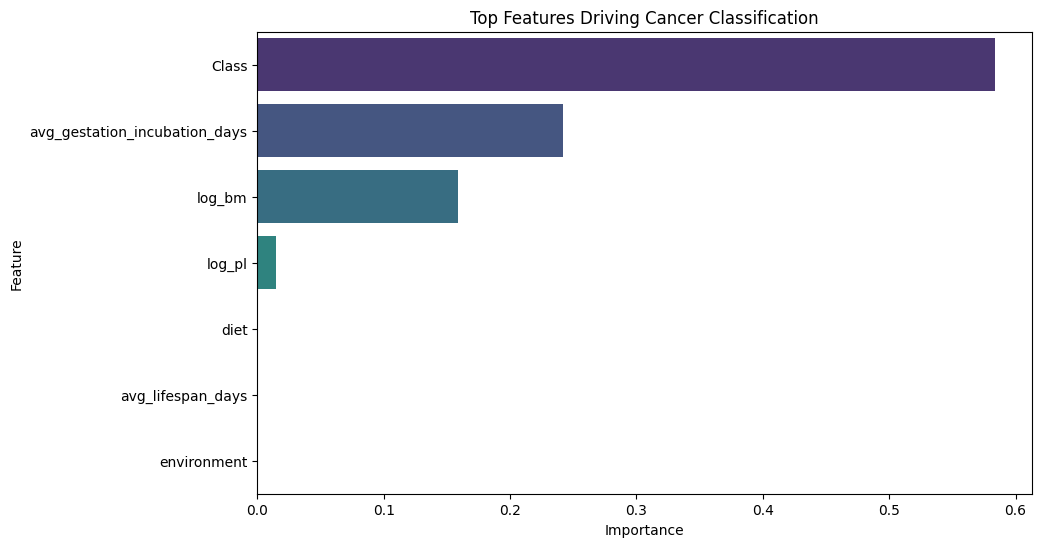

In [51]:

# Feature Importances
importances = model.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp_df.head(10),
    palette='viridis'
)
plt.title('Top Features Driving Cancer Classification')
plt.show()


In [54]:
df.head(3)

,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate,cancer_class,diet,avg_gestation_incubation_days,avg_lifespan_days,environment
0,Elephas_maximus,Mammalia,endothermic,Asian elephant,22,9,1,14.966083,6.940684,3.091042,4.545455,0,Herbivore,617,29200,Grasslands
1,Giraffa_camelopardalis,Mammalia,endothermic,Baringo giraffe,30,3,2,13.710144,6.421864,3.401197,6.666667,0,Herbivore,457,13870,Grasslands
2,Equus_grevyi,Mammalia,endothermic,Grevys zebra,21,3,2,12.919022,6.481683,3.044522,9.523810,0,Herbivore,390,14600,Grasslands


<Axes: xlabel='diet', ylabel='cancer_rate'>

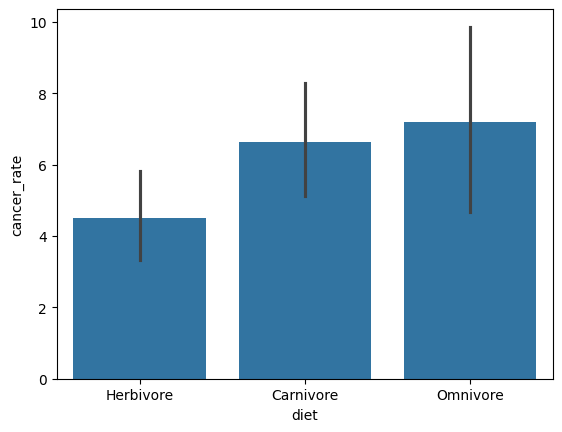

In [62]:
sns.barplot(x = 'diet', y = 'cancer_rate', data = df)

## Huh???

In [103]:
df_filtered = df[(df['Class'] == 'Aves')]
df_filtered.head(20)

,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate,cancer_class,diet,avg_gestation_incubation_days,avg_lifespan_days,environment
32,Rhea_americana,Aves,endothermic,Greater rhea,21,3,2,10.043249,6.197471,3.044522,9.523810,0,Herbivore,40,14600,Grasslands
41,Cygnus_cygnus,Aves,endothermic,Whooper swan,29,0,0,9.143131,5.375935,3.367296,0.000000,1,Herbivore,35,9125,Aquatic (Fresh Water)
47,Meleagris_gallopavo,Aves,endothermic,Domestic lavender turkey,71,10,8,8.664124,5.545301,4.262680,11.267606,0,Omnivore,28,4380,Forest
51,Haliaeetus_leucocephalus,Aves,endothermic,Bald eagle,20,1,0,8.455441,5.528618,2.995732,0.000000,1,Carnivore,35,18250,Forest
53,Spheniscus_humboldti,Aves,endothermic,Humboldt penguin,376,4,2,8.381692,5.337713,5.929589,0.531915,1,Carnivore,40,10950,Aquatic (Salt Water)
55,Pavo_cristatus,Aves,endothermic,Blue peafowl,31,1,0,8.332022,5.571738,3.433987,0.000000,1,Carnivore,28,8395,Forest
58,Ciconia_ciconia,Aves,endothermic,Abdims stork,41,0,0,8.144911,5.188178,3.713572,0.000000,1,Carnivore,30,11315,Grasslands
59,Pelecanus_occidentalis,Aves,endothermic,Brown pelican,23,2,1,8.139686,5.288532,3.135494,4.347826,0,Carnivore,30,10950,Aquatic (Salt Water)
61,Spheniscus_demersus,Aves,endothermic,Black-footed penguin,210,0,0,8.048823,5.317885,5.347108,0.000000,1,Carnivore,40,9855,Aquatic (Salt Water)
70,Eudyptes_chrysocome,Aves,endothermic,Rockhopper penguin,29,2,2,7.752700,5.291175,3.367296,6.896552,0,Carnivore,34,10585,Aquatic (Salt Water)


In [98]:
df[df["common_name"].str.contains("penguin", case=False, na=False)]


,Species,Class,therm,common_name,rec,neo,mal,log_bm,log_pl,log_rec,cancer_rate,cancer_class,diet,avg_gestation_incubation_days,avg_lifespan_days,environment
53,Spheniscus_humboldti,Aves,endothermic,Humboldt penguin,376,4,2,8.381692,5.337713,5.929589,0.531915,1,Carnivore,40,10950,Aquatic (Salt Water)
61,Spheniscus_demersus,Aves,endothermic,Black-footed penguin,210,0,0,8.048823,5.317885,5.347108,0.000000,1,Carnivore,40,9855,Aquatic (Salt Water)
70,Eudyptes_chrysocome,Aves,endothermic,Rockhopper penguin,29,2,2,7.752700,5.291175,3.367296,6.896552,0,Carnivore,34,10585,Aquatic (Salt Water)
